In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [ ]:
emotion_dataset = load_dataset('dair-ai/emotion')

train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [ ]:
train_label

Column([0, 0, 3, 2, 3, ...])

In [ ]:
label_name = emotion_dataset['train'].features['label'].names

In [ ]:
label_name

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train = pd.DataFrame(
    {
        'text' : train_text,
        'label' : [label_name[i] for i in train_label]
    }
)

In [ ]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
df_test = pd.DataFrame(
    {
        'text' : test_text,
        'label' : [label_name[i] for i in test_label]
    }
)

In [ ]:
df_train.isnull().sum()

,0
text,0
label,0


EDA

In [ ]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label', ylabel='count'>

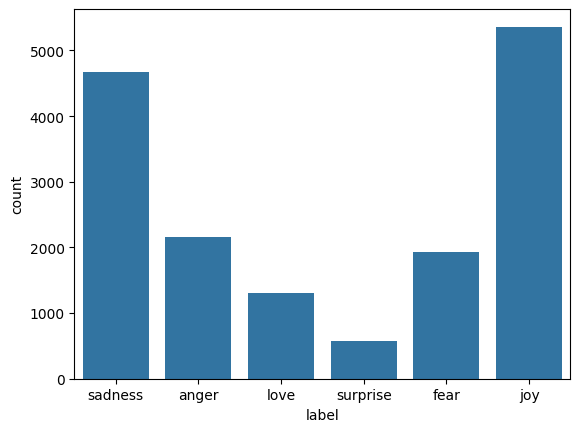

In [ ]:
sns.countplot(x='label',data=df_train)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words= max_words,oov_token= '<unk>' )
tokenizer.fit_on_texts(df_train['text'])

In [ ]:
train_sequences = tokenizer.texts_to_sequences(df_train['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['text'])

In [ ]:
padded_train_sequences = pad_sequences(train_sequences,maxlen=50,padding='post',truncating='post')
padded_test_sequences = pad_sequences(test_sequences,maxlen=50,padding='post',truncating='post')

In [ ]:
train_labels = np.array(train_label)
test_labels = np.array(test_label)
num_classes = len(np.unique(train_labels))
num_classes

print(f"Vocabulary size: {len(tokenizer.word_index)}")

Vocabulary size: 15213


class weights

In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes = np.unique(train_labels),
    y = train_labels
)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU


rnn_model = Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length = 50),
    SimpleRNN(units = 128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units = 64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences,test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight = class_weight_dict
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.1577 - loss: 2.0292 - val_accuracy: 0.2410 - val_loss: 1.7816
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.1451 - loss: 1.8800 - val_accuracy: 0.0780 - val_loss: 1.7634
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.1350 - loss: 1.8217 - val_accuracy: 0.2745 - val_loss: 1.7982
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.1443 - loss: 1.8092 - val_accuracy: 0.1570 - val_loss: 1.7723
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.1500 - loss: 1.8033 - val_accuracy: 0.3400 - val_loss: 1.7679


In [ ]:
rnn_loss ,rnn_accuracy = rnn_model.evaluate(padded_test_sequences,test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0780 - loss: 1.7634
RNN Loss: 1.763382911682129
RNN Accuracy: 0.07800000160932541


LSTM

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length = 50),
    LSTM(units = 128, return_sequences=True),
    Dropout(0.5),
    LSTM(units = 64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences,test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight = class_weight_dict
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 140ms/step - accuracy: 0.1631 - loss: 1.7950 - val_accuracy: 0.0330 - val_loss: 1.8097
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 135ms/step - accuracy: 0.1464 - loss: 1.7936 - val_accuracy: 0.0810 - val_loss: 1.7968
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 136ms/step - accuracy: 0.1536 - loss: 1.7931 - val_accuracy: 0.1315 - val_loss: 1.8002
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.0330 - loss: 1.8097
LSTM Loss: 1.8097221851348877
LSTM Accuracy: 0.032999999821186066


GRU

In [ ]:
gru_model = Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length = 50),
    GRU(units = 128, return_sequences=True),
    Dropout(0.5),
    GRU(units = 64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences,test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight = class_weight_dict
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 129ms/step - accuracy: 0.1462 - loss: 1.7964 - val_accuracy: 0.2865 - val_loss: 1.7860
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 125ms/step - accuracy: 0.1670 - loss: 1.7954 - val_accuracy: 0.1380 - val_loss: 1.8030
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 126ms/step - accuracy: 0.1616 - loss: 1.7941 - val_accuracy: 0.0330 - val_loss: 1.8311
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2865 - loss: 1.7860
GRU Loss: 1.7860273122787476
GRU Accuracy: 0.2865000069141388


In [ ]:
results_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Loss': [rnn_loss, lstm_loss, gru_loss],
    'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Accuracy',ascending=False)

results_df

,Model,Loss,Accuracy
2,GRU,1.786027,0.2865
0,RNN,1.763383,0.0780
1,LSTM,1.809722,0.0330


In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length = 50),
    Bidirectional(GRU(128,return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')]
)


BiGRU.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiGRU.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences,test_labels),
    epochs=20,
    batch_size=32,
    class_weight = class_weight_dict,
    callbacks=[early_stopping],
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 183s 349ms/step - accuracy: 0.5705 - loss: 1.0256 - val_accuracy: 0.8730 - val_loss: 0.4338
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 177s 354ms/step - accuracy: 0.9152 - loss: 0.2445 - val_accuracy: 0.9045 - val_loss: 0.3099
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 171s 341ms/step - accuracy: 0.9438 - loss: 0.1567 - val_accuracy: 0.9165 - val_loss: 0.2270
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 167s 335ms/step - accuracy: 0.9588 - loss: 0.1156 - val_accuracy: 0.9190 - val_loss: 0.2750
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 336ms/step - accuracy: 0.9684 - loss: 0.0932 - val_accuracy: 0.9200 - val_loss: 0.2652
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 166s 333ms/step - accuracy: 0.9749 - loss: 0.0718 - val_accuracy: 0.9220 - val_loss: 0.2691


In [ ]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequences, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9165 - loss: 0.2270
BiGRU Loss: 0.227020725607872
BiGRU Accuracy: 0.9164999723434448


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       581
           1       0.96      0.91      0.94       695
           2       0.77      0.87      0.82       159
           3       0.93      0.93      0.93       275
           4       0.90      0.85      0.87       224
           5       0.58      0.98      0.73        66

    accuracy                           0.92      2000
   macro avg       0.85      0.92      0.87      2000
weighted avg       0.93      0.92      0.92      2000


Confusion Matrix:


<Axes: >

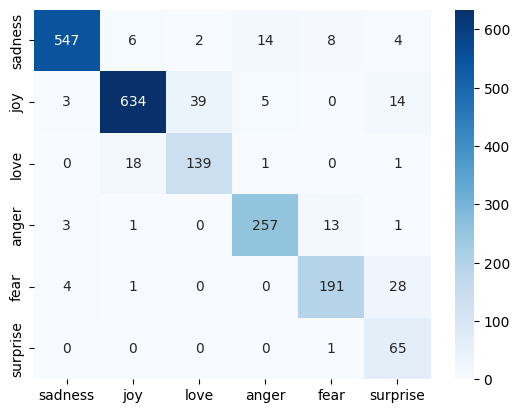

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = BiGRU.predict(padded_test_sequences)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(test_labels, y_pred_classes))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(test_labels, y_pred_classes),annot=True,fmt='d',cmap='Blues',xticklabels=label_name,yticklabels=label_name)


In [ ]:
sample_texts = [
    "I can't believe how hammpy I am right now, this is amazing.",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely suprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}")
    print(f"Predicted Label: {label_name[sample_predictions[i]]}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Text: I can't believe how hammpy I am right now, this is amazing.
Predicted Label: surprise

Text: I feel so alone and hopeless today.
Predicted Label: sadness

Text: I am furious that they cancelled the trip at the last minute.
Predicted Label: anger

Text: I feel terrified when walking down dark alleyways alone.
Predicted Label: fear

Text: I was shocked and completely suprised by the unexpected gift!
Predicted Label: surprise



In [ ]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir,exist_ok=True)

In [ ]:
#save bigru model

BiGRU.save(os.path.join(model_dir, "BiGRU_Model.keras"))

In [ ]:
# save tokenizer

with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer,file)